In [14]:
# =============================================================================
# CONFIGURATION & IMPORTS
# =============================================================================

# Configuration
TRIAL_NUMBER = 10  # Trial to analyze (has real movement data)
TIME_BIN_SIZE = 0.05  # seconds (50 ms bins) - better for spike detection
SAMPLING_RATE = 30000  # Hz
SPIKE_CHANNELS = [0, 1, 2, 3, 6, 32, 39, 40, 41, 42, 46, 49, 53, 67, 68, 73, 74, 75, 76, 77, 84]

# Spike detection parameters
THRESHOLD_FACTOR = 5.0  # Spike detection threshold
SPIKE_WINDOW = (-10, 32)  # samples around spike

# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Modular imports - Updated to use spike detection
from utils.diagnostics import (
    diagnose_trial_data, 
    check_behavioral_data_availability,
    find_trials_with_movement,
    run_comprehensive_diagnostic
)
from utils.analysis import (
    SpikeAnalyzer,
    print_spike_summary
)
from utils.visualization import (
    plot_behavior_raster_psth,
    plot_spike_raster_behavioral,
    plot_spike_firing_rates,
    plot_spike_channel_comparison,
    plot_spike_channel_detail
)

# Set up plotting
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

print(f"🧠 Neural Feature Exploration with Spike Detection")
print(f"📊 Configuration: Trial {TRIAL_NUMBER}, {TIME_BIN_SIZE*1000:.0f}ms bins, {len(SPIKE_CHANNELS)} channels")
print(f"🔍 Spike detection: {THRESHOLD_FACTOR}x threshold, {SPIKE_WINDOW} sample window")


🧠 Neural Feature Exploration with Spike Detection
📊 Configuration: Trial 10, 50ms bins, 21 channels
🔍 Spike detection: 5.0x threshold, (-10, 32) sample window


In [15]:
# Initialize spike analyzer
spike_analyzer = SpikeAnalyzer(
    spike_channels=SPIKE_CHANNELS,
    sampling_rate=SAMPLING_RATE,
    threshold_factor=THRESHOLD_FACTOR,
    spike_window=SPIKE_WINDOW,
    bin_size=TIME_BIN_SIZE
)

print(f"✅ Spike analyzer initialized successfully!")


🔧 Filters initialized (300-3000 Hz bandpass, 500 Hz highpass)
🔍 SpikeDetector initialized:
  • Sampling rate: 30.0 kHz
  • Threshold factor: 5.0
  • Spike window: (-10, 32)
  • Good channels: 21
🔗 NeuralBehavioralAligner initialized:
  • Bin size: 50ms
  • Interpolation: linear
🔍 SpikeAnalyzer initialized:
  • 21 channels
  • 5.0x threshold
  • 50ms bins
✅ Spike analyzer initialized successfully!


In [16]:
# Run basic diagnostics and find trials with movement
print("🔍 Running diagnostics...")

# Check behavioral data availability
behavioral_summary = check_behavioral_data_availability(max_trials=20)

# Find trials with movement
movement_trials = find_trials_with_movement(min_movement_threshold=0.01, max_trials=20)

# Diagnose specific trial
trial_data = diagnose_trial_data(TRIAL_NUMBER, SAMPLING_RATE)

if trial_data:
    print(f"\n✅ Trial {TRIAL_NUMBER} diagnostics passed!")
    print(f"🎯 Recommended trials with good movement:")
    print(f"   {movement_trials[:10]}")  # Show first 10 trials with movement
else:
    print("❌ Trial diagnostic failed!")
    trial_data = None


🔍 Running diagnostics...

🔍 CHECKING BEHAVIORAL DATA AVAILABILITY (first 20 trials):
--------------------------------------------------
Trial  Neural  Vel_X   Vel_Y   Timestamps  Outcome  VelX Shape   VelX Range          
----------------------------------------------------------------------------------------------------
1      ✅       ✅       ✅       ✅           lose     (1407,)      -0.496 to 0.724     
2      ✅       ✅       ✅       ✅           win      (106,)       -0.406 to 0.503     
3      ✅       ✅       ✅       ✅           win      (133,)       -0.384 to 0.214     
4      ✅       ✅       ✅       ✅           win      (120,)       -0.660 to 0.243     
5      ✅       ✅       ✅       ✅           win      (175,)       -0.666 to 0.000     
6      ✅       ✅       ✅       ✅           win      (68,)        0.000 to 0.965      
7      ✅       ✅       ✅       ✅           win      (96,)        -0.812 to 0.000     
8      ✅       ✅       ✅       ✅           win      (94,)        -0.703 to 

In [17]:
# Perform spike analysis using the modular analyzer
print(f"🔍 Analyzing trial {TRIAL_NUMBER} with spike detection...")

# Analyze trial using modular spike analyzer
analysis_results = spike_analyzer.analyze_trial(TRIAL_NUMBER)

if analysis_results['success']:
    print(f"✅ Spike analysis completed successfully!")
    
    # Display comprehensive summary
    print_spike_summary(analysis_results)
    
    # Get summary statistics
    summary_stats = spike_analyzer.get_summary_statistics(analysis_results)
    print(f"\n📈 Summary Statistics:")
    for key, value in summary_stats.items():
        print(f"   • {key}: {value}")
    
    # Analyze neural-behavioral correlation
    correlation_analysis = spike_analyzer.analyze_neural_behavioral_correlation(analysis_results)
    if correlation_analysis['success']:
        print(f"\n🧠 Neural-Behavioral Correlation:")
        print(f"   • Population correlation: {correlation_analysis['population_correlation']:.3f}")
        print(f"   • Top channels correlations:")
        for channel, corr in correlation_analysis['channel_correlations']:
            print(f"     - Channel {channel}: {corr:.3f}")
    
else:
    print(f"❌ Spike analysis failed: {analysis_results.get('error', 'Unknown error')}")
    analysis_results = None


🔍 Analyzing trial 10 with spike detection...
🔍 Analyzing trial 10...
🔍 Extracting spike features from trial 10
🔍 Detecting spikes across 21 channels...
🔧 Preprocessing neural data: (96, 93372)
✅ Signal preprocessing complete
✅ Spike detection complete: 916 spikes across 21 channels
🔥 Computing firing rates (bin size: 50ms)
✅ Firing rates computed: 59 bins x 21 channels
✅ Features extracted for trial 10
📂 Loading trial 10 data...
✅ Trial 10 loaded:
  • Neural data: (96, 93372)
  • Velocity data: 114 samples
  • Duration: 2.91s
🔍 Detecting spikes across 21 channels...
🔧 Preprocessing neural data: (96, 93372)
✅ Signal preprocessing complete
✅ Spike detection complete: 916 spikes across 21 channels
✅ Trial 10 analysis complete!
✅ Spike analysis completed successfully!
📊 SPIKE ANALYSIS SUMMARY
🔍 Detection Results:
   • Total channels analyzed: 21
   • Total spikes detected: 916
   • Mean firing rate: 13.9 Hz
   • Active channels (>50 spikes): 7

⭐ Quality Assessment:
   • Mean SNR: 7.14
   

📊 Creating comprehensive spike raster and behavioral visualization...
🎨 Creating enhanced behavior-raster-PSTH plot for trial 10...
🔍 Detecting spikes for enhanced raster plot...
📊 Computing PSTH with advanced kernel smoothing...
🎯 Creating enhanced vertline raster plot...


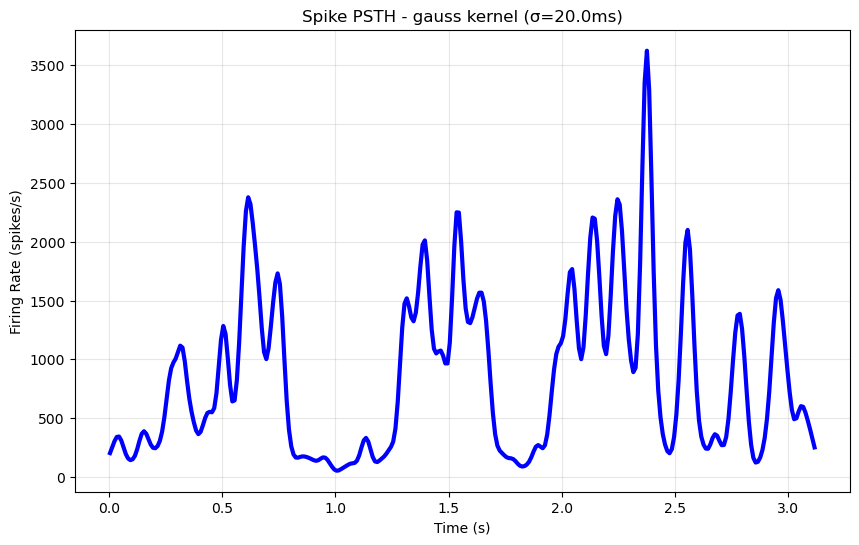

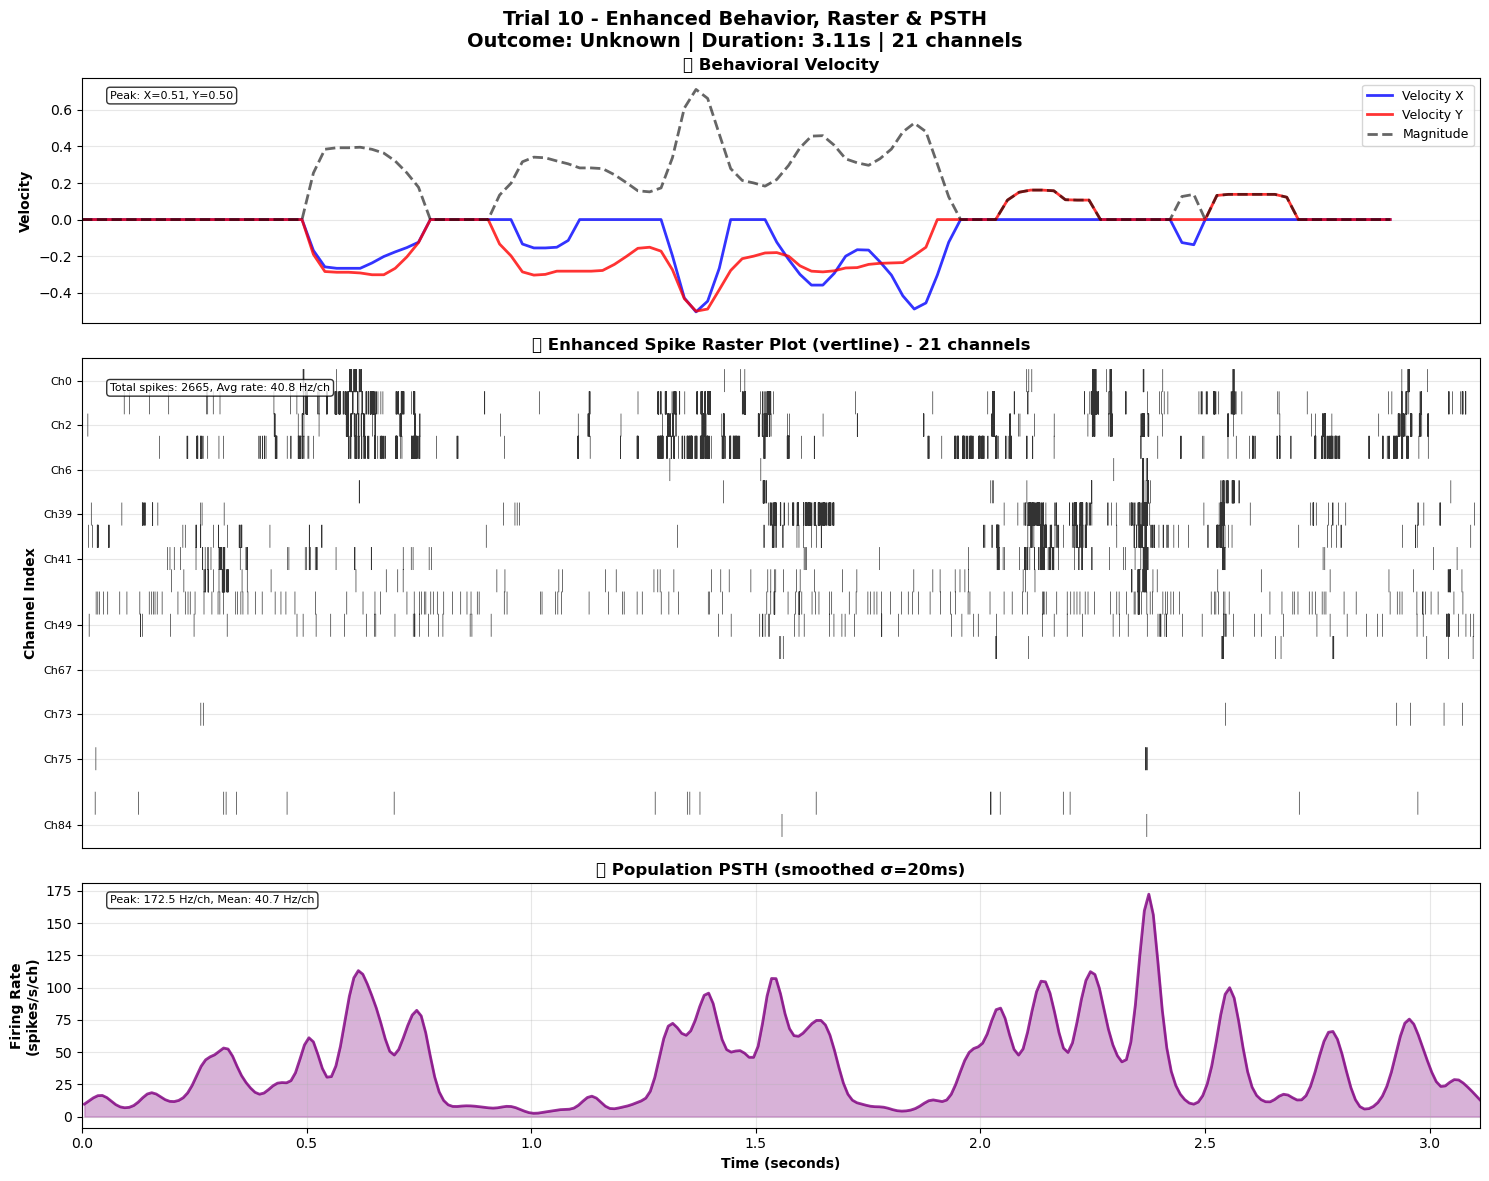


📊 Enhanced Trial 10 Summary:
   Neural data: 96 channels, 93372 samples
   Spike detection: 2665 spikes detected
   Average firing rate: 40.77 Hz per channel
   Raster plot type: vertline
   PSTH resolution: 10.0ms bins, smoothed with σ=20ms
   Behavioral data: 114 samples
   Velocity peaks: X=0.505, Y=0.501
   Most active channels: ['Ch3(597)', 'Ch1(408)', 'Ch39(345)', 'Ch2(323)', 'Ch40(214)']


In [18]:
# 1. Comprehensive spike raster and behavioral visualization
if analysis_results is not None and analysis_results['success']:
    print("📊 Creating comprehensive spike raster and behavioral visualization...")
    
    # Use modular visualization - fixed function call
    plot_behavior_raster_psth(
        analysis_results['trial_data'], 
        SPIKE_CHANNELS,  # Pass the spike channels list (not firing_rates)
        trial_number=TRIAL_NUMBER
    )
    
    # Alternative: Use new spike-based raster plot
    # plot_spike_raster_behavioral(analysis_results, TRIAL_NUMBER)
    
else:
    print("❌ Cannot create visualization - no valid analysis results")

📊 Creating individual channel firing rate analysis...


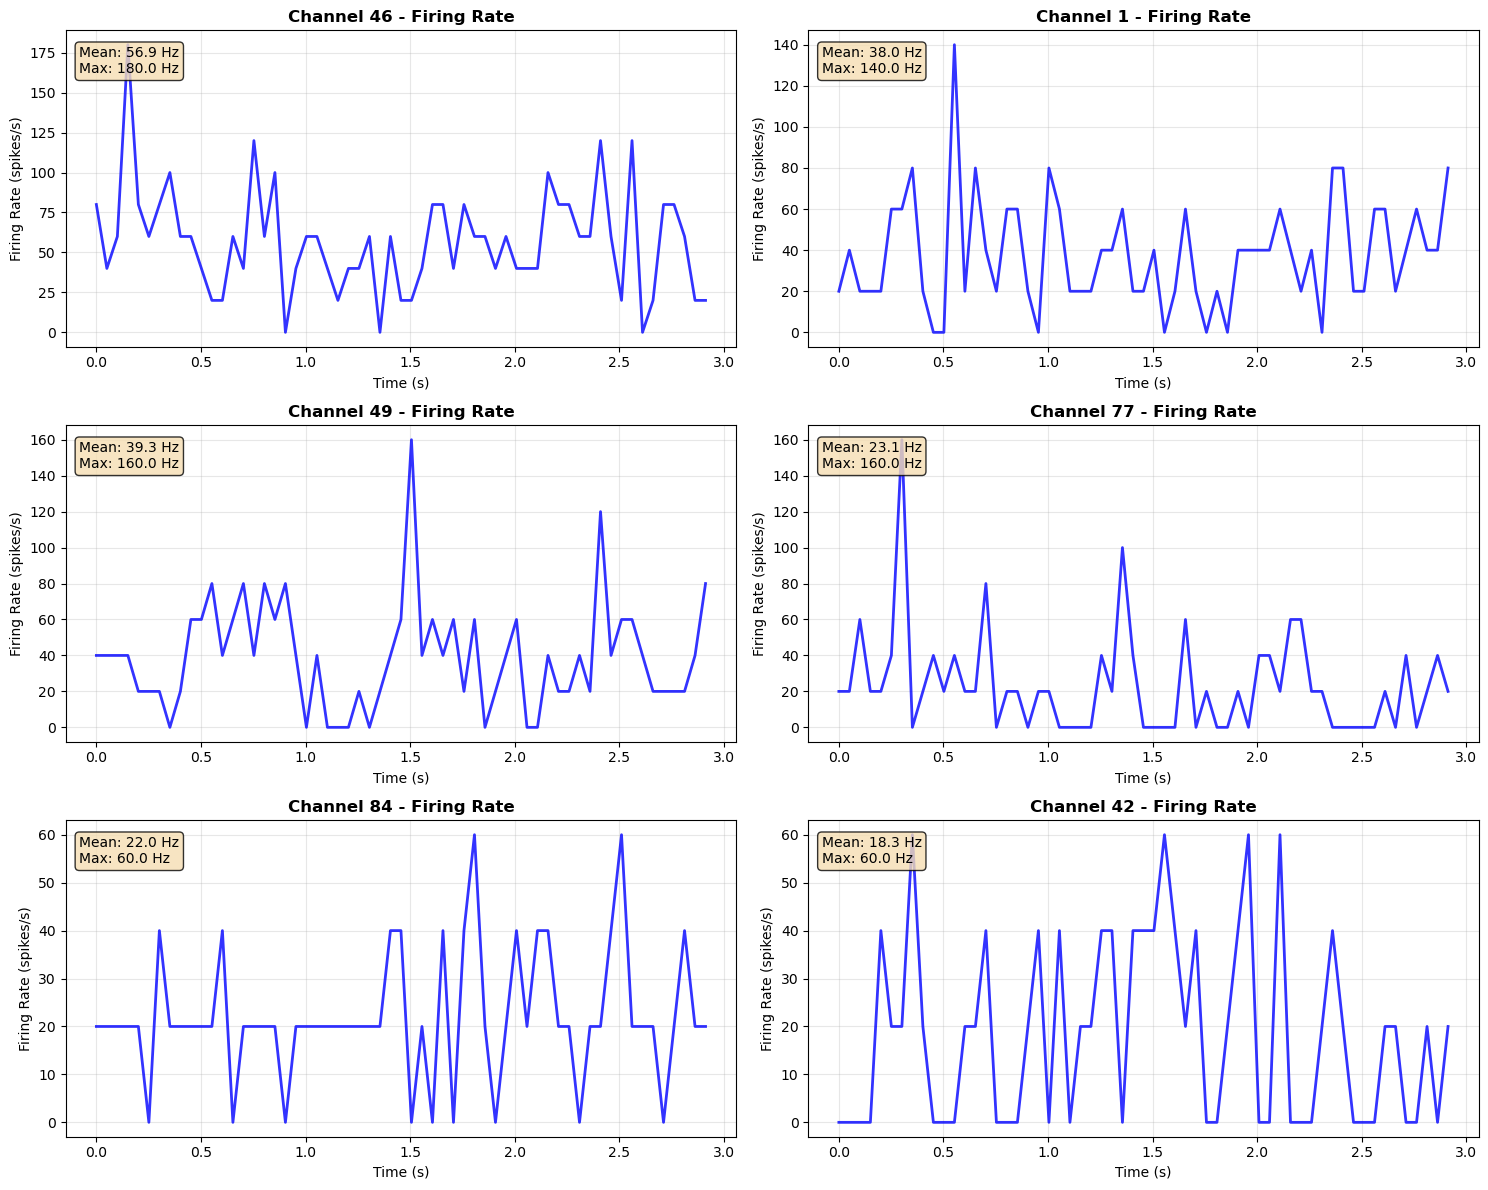

✅ Individual channel analysis complete!
   • Channels analyzed: 6


In [19]:
# 2. Individual channel firing rate analysis
if analysis_results is not None and analysis_results['success']:
    print("📊 Creating individual channel firing rate analysis...")
    
    # Use modular visualization function
    plot_spike_firing_rates(analysis_results, n_channels=6)
    
else:
    print("❌ Cannot create visualization - no valid analysis results")


📊 Creating channel comparison and spike statistics...


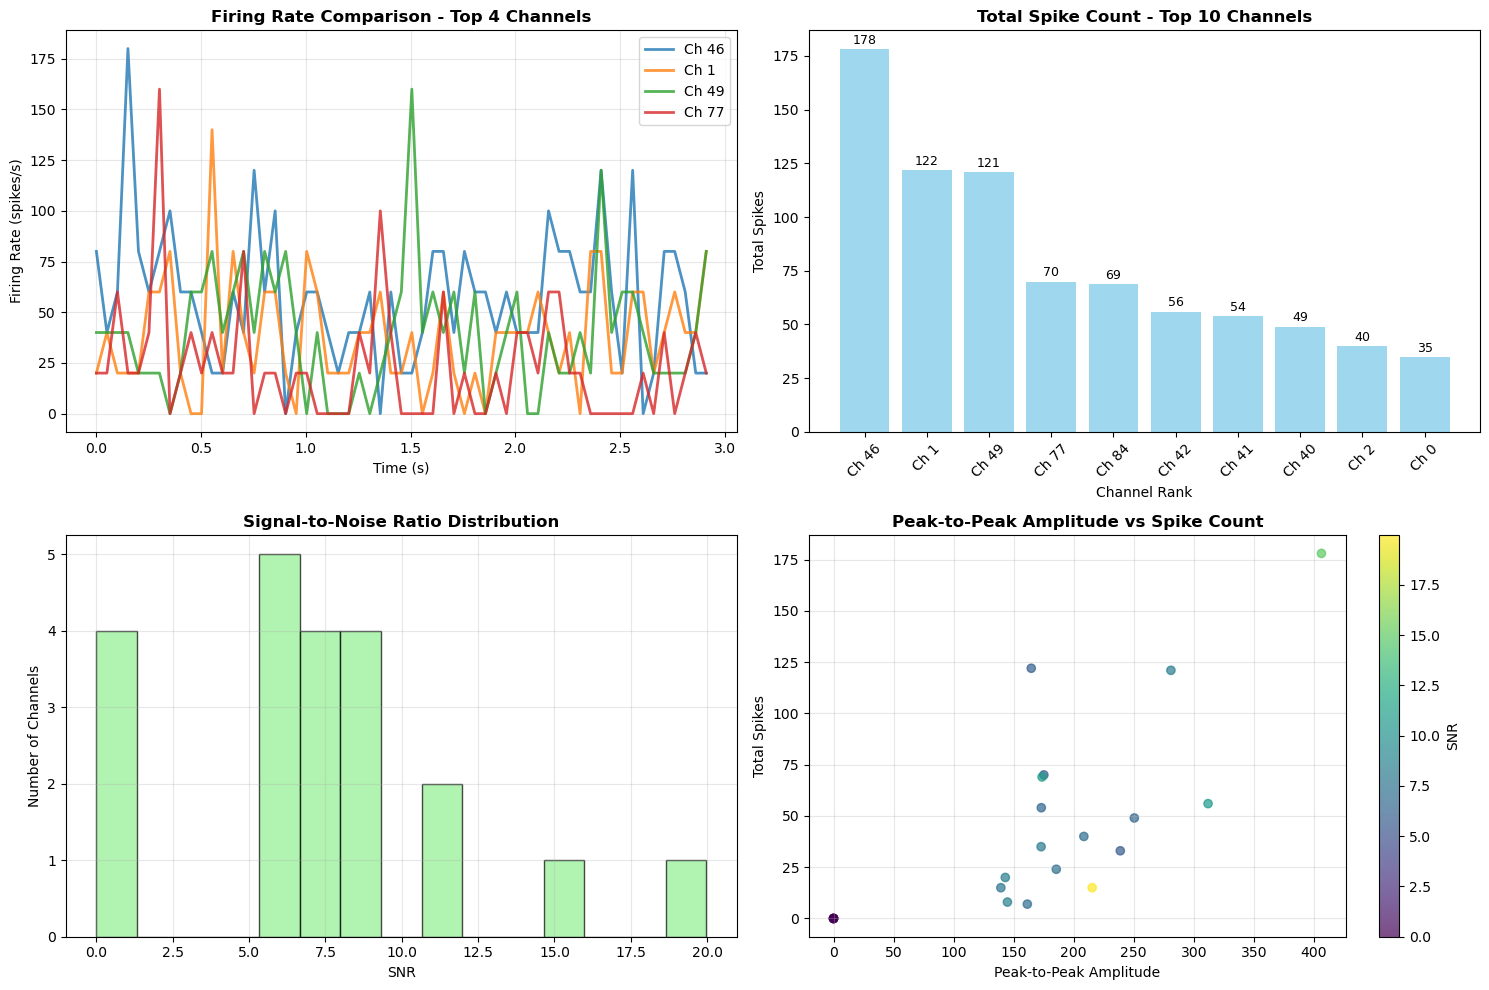

✅ Channel comparison complete!
   • Channels compared: 4
   • Quality metrics: 21 channels


In [20]:
# 3. Channel comparison and spike statistics
if analysis_results is not None and analysis_results['success']:
    print("📊 Creating channel comparison and spike statistics...")
    
    # Use modular visualization function
    plot_spike_channel_comparison(analysis_results)
    
else:
    print("❌ Cannot create visualization - no valid analysis results")


📊 Creating detailed analysis of the most active channel...
📊 Creating detailed analysis for channel 46...


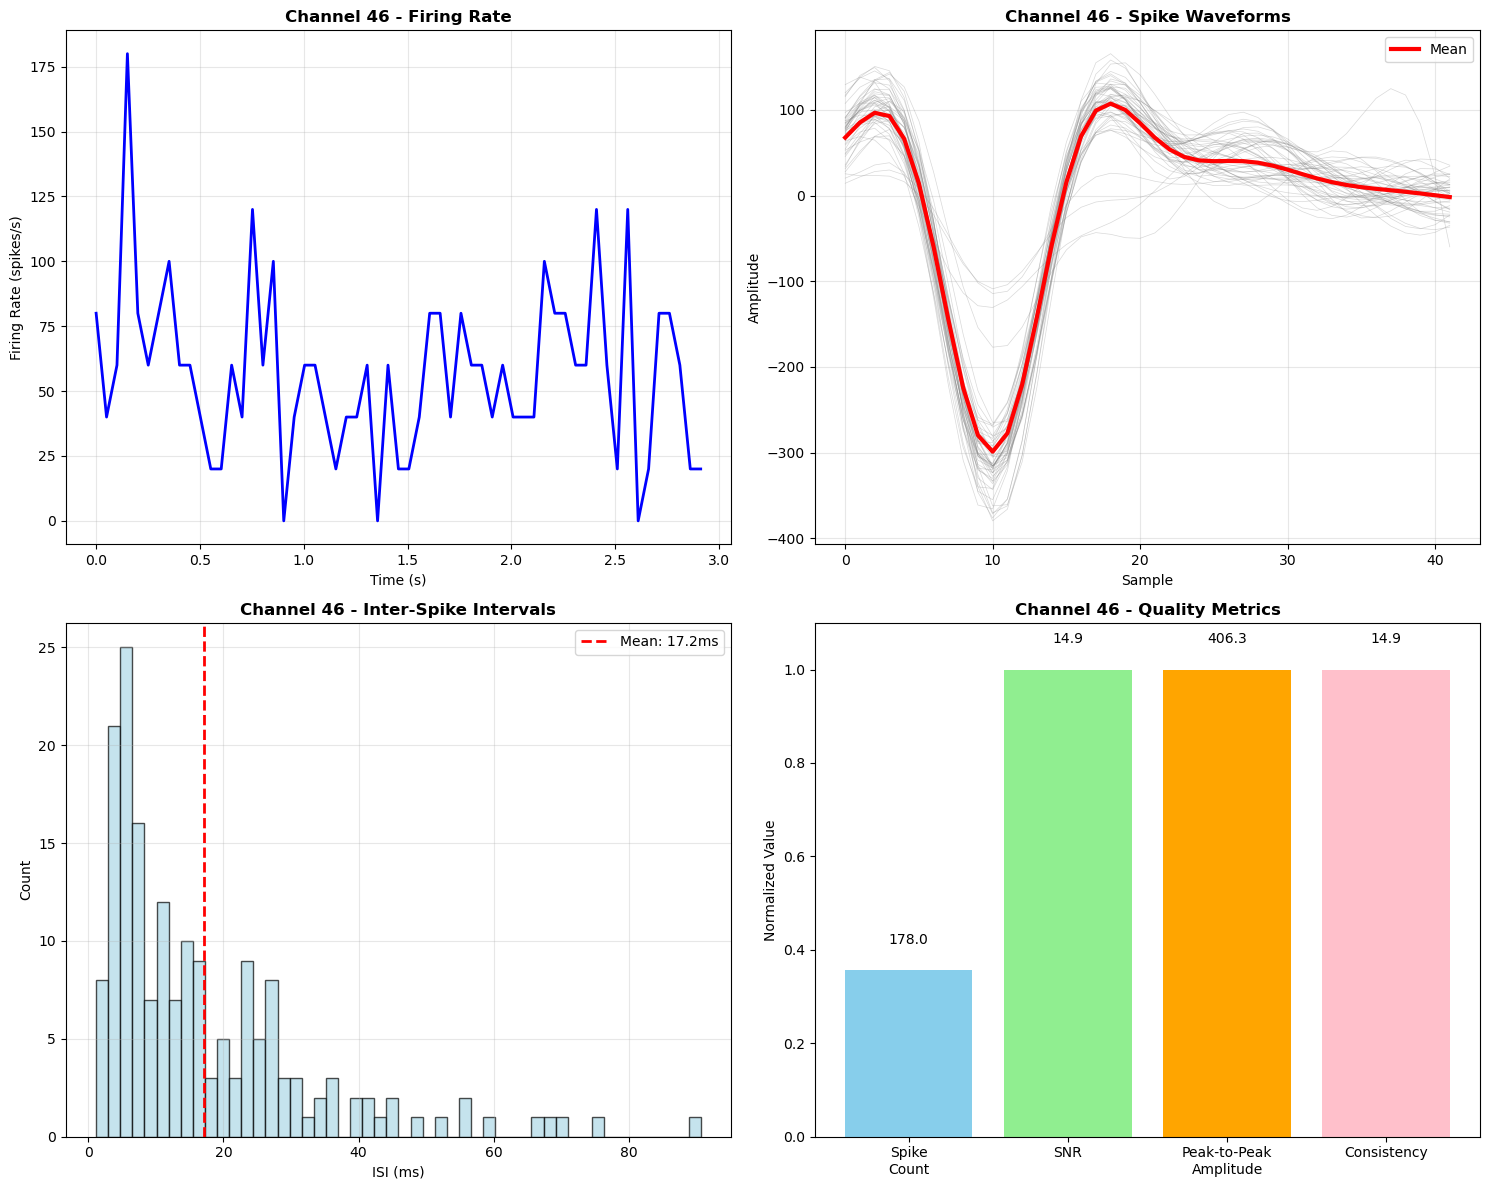

✅ Detailed analysis complete for channel 46!
   • Total spikes: 178
   • Mean firing rate: 56.9 Hz
   • Peak firing rate: 180.0 Hz


In [21]:
# 4. Detailed analysis of the most active channel
if analysis_results is not None and analysis_results['success']:
    print("📊 Creating detailed analysis of the most active channel...")
    
    # Use modular visualization function
    plot_spike_channel_detail(analysis_results)
    
else:
    print("❌ Cannot create visualization - no valid analysis results")


📊 Detailed analysis of most active channel: 46


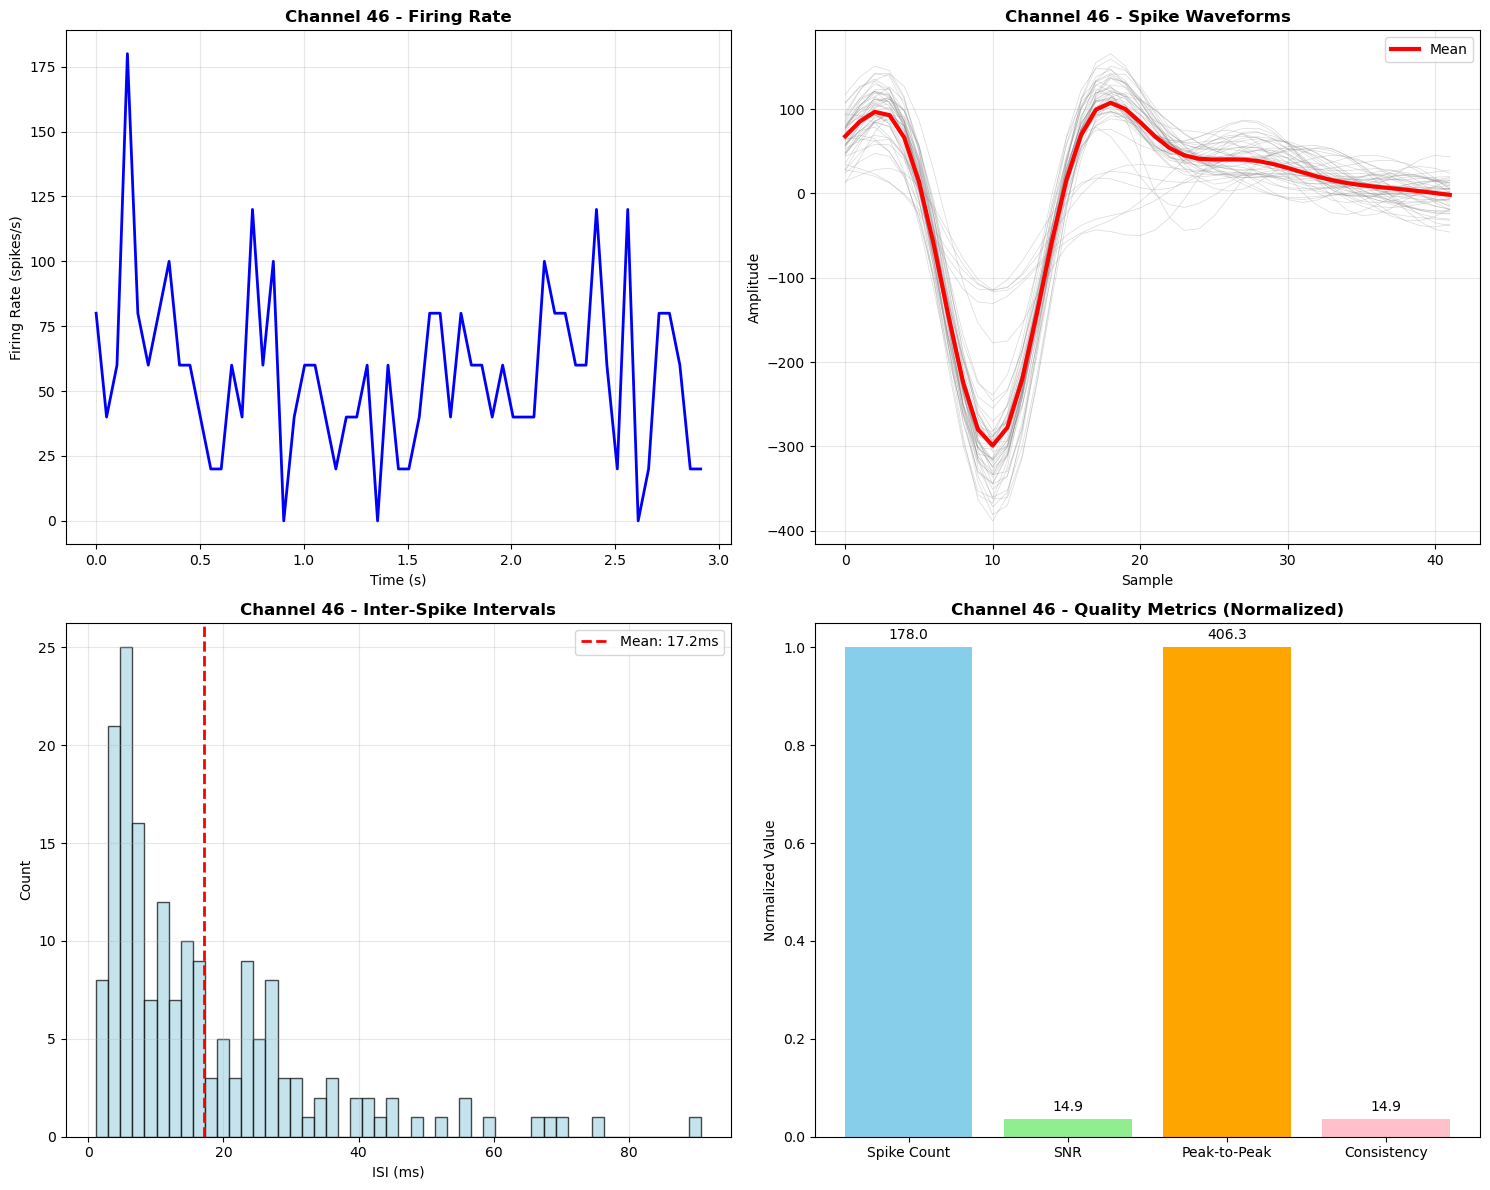

✅ Detailed analysis complete for channel 46!
   • Total spikes: 178
   • Mean firing rate: 56.9 Hz
   • Peak firing rate: 180.0 Hz


In [22]:
# 4. Detailed analysis of the most active channel
if analysis_results is not None and analysis_results['success']:
    # Extract variables from analysis_results
    firing_rates = analysis_results['firing_rates']
    spike_data = analysis_results['spike_data']
    top_channels = analysis_results['top_channels']
    trial_data = analysis_results['trial_data']
    quality_metrics = analysis_results['quality_metrics']
    
    most_active_channel = top_channels[0]
    print(f"📊 Detailed analysis of most active channel: {most_active_channel}")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Firing rate over time
    ax1 = axes[0, 0]
    if most_active_channel in firing_rates:
        time_bins = np.linspace(0, trial_data['metadata']['duration'], len(firing_rates[most_active_channel]))
        ax1.plot(time_bins, firing_rates[most_active_channel], 'b-', linewidth=2)
        ax1.set_title(f'Channel {most_active_channel} - Firing Rate', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Firing Rate (spikes/s)')
        ax1.grid(True, alpha=0.3)
    
    # Plot 2: Spike waveforms
    ax2 = axes[0, 1]
    if most_active_channel in spike_data:
        waveforms = spike_data[most_active_channel]['spike_waveforms']
        if len(waveforms) > 0:
            # Plot individual waveforms (sample)
            n_sample = min(50, len(waveforms))
            sample_indices = np.random.choice(len(waveforms), n_sample, replace=False)
            
            for i in sample_indices:
                ax2.plot(waveforms[i], 'gray', alpha=0.3, linewidth=0.5)
            
            # Plot mean waveform
            mean_waveform = np.mean(waveforms, axis=0)
            ax2.plot(mean_waveform, 'r-', linewidth=3, label='Mean')
            ax2.set_title(f'Channel {most_active_channel} - Spike Waveforms', fontsize=12, fontweight='bold')
            ax2.set_xlabel('Sample')
            ax2.set_ylabel('Amplitude')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
    
    # Plot 3: Inter-spike interval histogram
    ax3 = axes[1, 0]
    if most_active_channel in spike_data:
        spike_times = spike_data[most_active_channel]['spike_times']
        if len(spike_times) > 1:
            isis = np.diff(spike_times) / SAMPLING_RATE * 1000  # Convert to milliseconds
            ax3.hist(isis, bins=50, color='lightblue', alpha=0.7, edgecolor='black')
            ax3.set_title(f'Channel {most_active_channel} - Inter-Spike Intervals', fontsize=12, fontweight='bold')
            ax3.set_xlabel('ISI (ms)')
            ax3.set_ylabel('Count')
            ax3.grid(True, alpha=0.3)
            
            # Add statistics
            ax3.axvline(np.mean(isis), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(isis):.1f}ms')
            ax3.legend()
    
    # Plot 4: Channel quality metrics
    ax4 = axes[1, 1]
    if most_active_channel in quality_metrics['channel'].values:
        ch_metrics = quality_metrics[quality_metrics['channel'] == most_active_channel].iloc[0]
        
        metrics_names = ['Spike Count', 'SNR', 'Peak-to-Peak', 'Consistency']
        metrics_values = [ch_metrics['n_spikes'], ch_metrics['snr'], 
                         ch_metrics['peak_to_peak'], ch_metrics['consistency']]
        
        # Normalize values for comparison (0-1 scale)
        normalized_values = []
        for i, value in enumerate(metrics_values):
            if i == 0:  # Spike count
                normalized_values.append(value / quality_metrics['n_spikes'].max())
            else:
                max_val = quality_metrics[['snr', 'peak_to_peak', 'consistency']].max().max()
                normalized_values.append(value / max_val if max_val > 0 else 0)
        
        bars = ax4.bar(metrics_names, normalized_values, color=['skyblue', 'lightgreen', 'orange', 'pink'])
        ax4.set_title(f'Channel {most_active_channel} - Quality Metrics (Normalized)', fontsize=12, fontweight='bold')
        ax4.set_ylabel('Normalized Value')
        
        # Add actual values as text
        for bar, actual_value in zip(bars, metrics_values):
            ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{actual_value:.1f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Detailed analysis complete for channel {most_active_channel}!")
    if most_active_channel in spike_data:
        print(f"   • Total spikes: {spike_data[most_active_channel]['n_spikes']}")
        print(f"   • Mean firing rate: {np.mean(firing_rates[most_active_channel]):.1f} Hz")
        print(f"   • Peak firing rate: {np.max(firing_rates[most_active_channel]):.1f} Hz")
    
else:
    print("❌ Cannot create detailed analysis - no valid analysis results")


🔗 NEURAL-BEHAVIORAL CORRELATION ANALYSIS:
✅ Population firing rate vs velocity correlation: -0.178
   Neural activity peak: 520.0 spikes/s
   Velocity peak: 0.7 mm/s
   Time bins analyzed: 59

📊 Individual Channel Correlations (Top 5):
   Channel 46: -0.255
   Channel 40: -0.202
   Channel 42: 0.156
   Channel 2: -0.112
   Channel 84: 0.110

📊 SPIKE DETECTION SUMMARY:
   • Total channels analyzed: 21
   • Total spikes detected: 916
   • Mean firing rate across channels: 13.9 Hz
   • High-quality channels (SNR > 3): 17
   • Active channels (>50 spikes): 7

🏆 TOP PERFORMING CHANNELS:
   1. Channel 46: 178.0 spikes, 56.9 Hz (avg), 180.0 Hz (peak), SNR: 14.9
   2. Channel 1: 122.0 spikes, 38.0 Hz (avg), 140.0 Hz (peak), SNR: 5.9
   3. Channel 49: 121.0 spikes, 39.3 Hz (avg), 160.0 Hz (peak), SNR: 8.4
   4. Channel 77: 70.0 spikes, 23.1 Hz (avg), 160.0 Hz (peak), SNR: 5.8
   5. Channel 84: 69.0 spikes, 22.0 Hz (avg), 60.0 Hz (peak), SNR: 11.0
🔧 Filters initialized (300-3000 Hz bandpass, 500

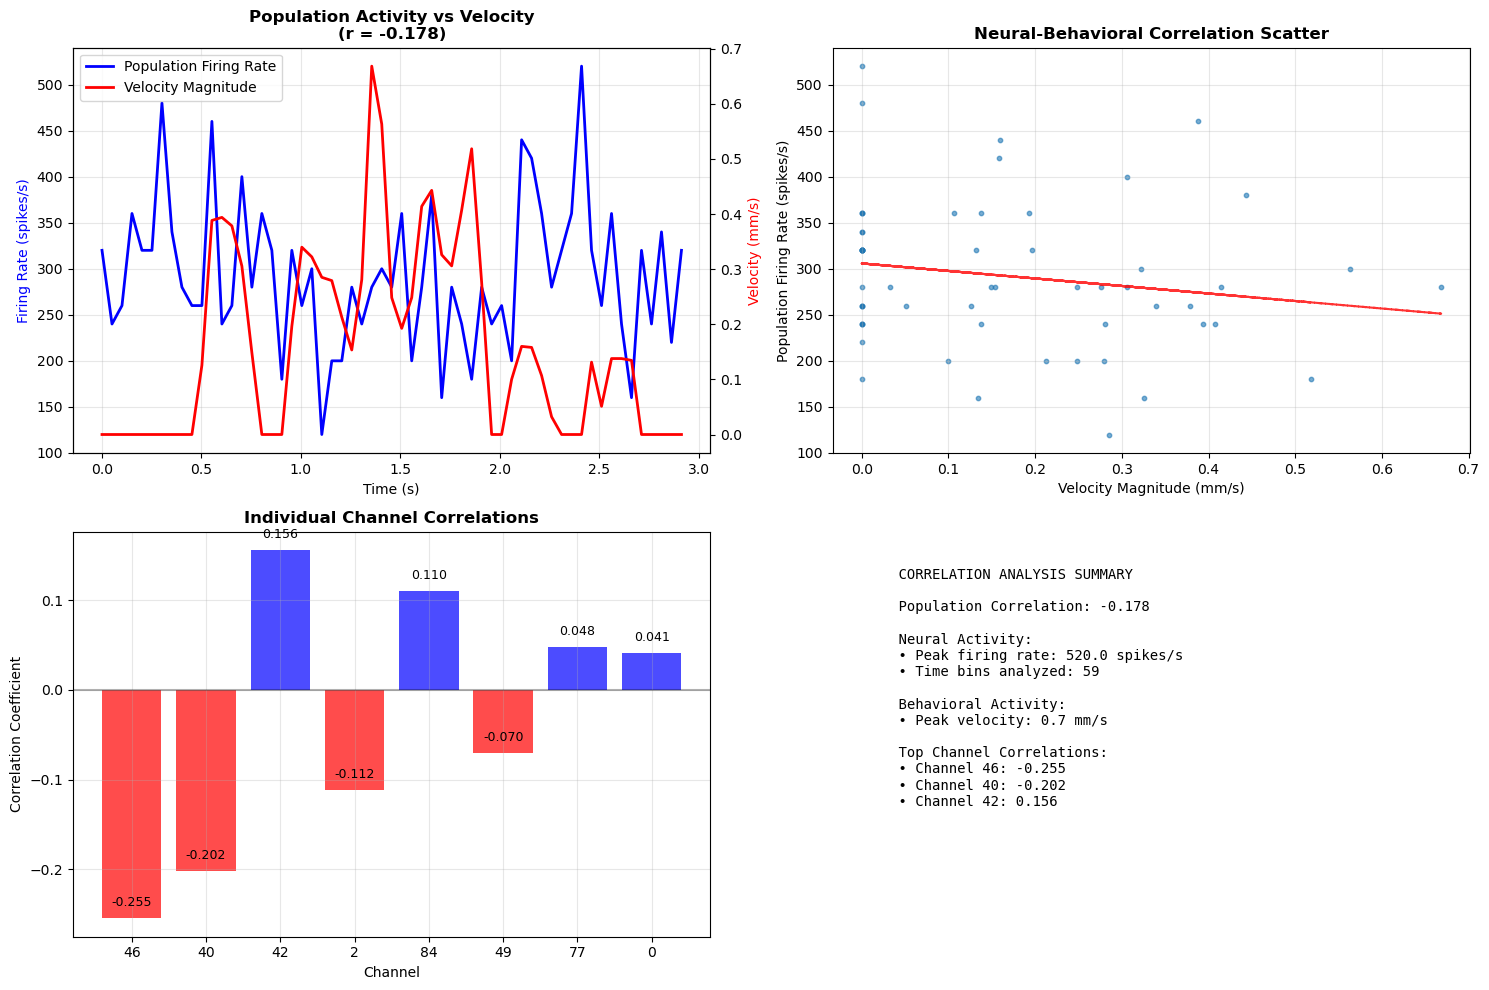

✅ Neural-behavioral correlation analysis complete!
   • Population correlation: -0.178
   • Top channel correlations: ['Ch 46: -0.255', 'Ch 40: -0.202', 'Ch 42: 0.156']


In [23]:
# Analyze neural-behavioral correlation using modular functions
if analysis_results is not None and analysis_results['success']:
    print("🔗 NEURAL-BEHAVIORAL CORRELATION ANALYSIS:")
    print("=" * 50)
    
    # Use modular correlation analysis
    correlation_results = spike_analyzer.analyze_neural_behavioral_correlation(analysis_results)
    
    if correlation_results['success']:
        print(f"✅ Population firing rate vs velocity correlation: {correlation_results['population_correlation']:.3f}")
        print(f"   Neural activity peak: {correlation_results['stats']['neural_peak']:.1f} spikes/s")
        print(f"   Velocity peak: {correlation_results['stats']['velocity_peak']:.1f} mm/s")
        print(f"   Time bins analyzed: {correlation_results['stats']['time_bins_analyzed']}")
        
        print(f"\n📊 Individual Channel Correlations (Top 5):")
        for channel, corr in correlation_results['channel_correlations'][:5]:
            print(f"   Channel {channel}: {corr:.3f}")
    else:
        print(f"⚠️  {correlation_results['error']}")
    
    # Use modular summary function
    from utils.analysis import get_comprehensive_trial_summary
    summary = get_comprehensive_trial_summary(analysis_results)
    
    if summary['success']:
        print(f"\n📊 SPIKE DETECTION SUMMARY:")
        print(f"   • Total channels analyzed: {summary['total_channels_analyzed']}")
        print(f"   • Total spikes detected: {summary['total_spikes']}")
        print(f"   • Mean firing rate across channels: {summary['mean_firing_rate']:.1f} Hz")
        print(f"   • High-quality channels (SNR > 3): {summary['high_quality_channels']}")
        print(f"   • Active channels (>50 spikes): {summary['active_channels']}")
        
        print(f"\n🏆 TOP PERFORMING CHANNELS:")
        for i, ch_info in enumerate(summary['top_channels'][:5]):
            print(f"   {i+1}. Channel {ch_info['channel']}: {ch_info['n_spikes']} spikes, {ch_info['mean_rate']:.1f} Hz (avg), {ch_info['max_rate']:.1f} Hz (peak), SNR: {ch_info['snr']:.1f}")
    
    # Create correlation visualization
    from utils.visualization import plot_neural_behavioral_correlation_analysis
    plot_neural_behavioral_correlation_analysis(analysis_results, TRIAL_NUMBER)
            
else:
    print("❌ Cannot perform neural-behavioral correlation analysis - no valid analysis results")


In [24]:
# 🔥 Extract Most Active Channels for Visualizations
# Define most_active_channels based on spike detection results

if analysis_results is not None and analysis_results['success']:
    # Extract quality_metrics from analysis_results
    quality_metrics = analysis_results['quality_metrics']
    
    most_active_channels = quality_metrics.nlargest(10, 'n_spikes')['channel'].tolist()
    print(f"🔥 Most active channels (by spike count): {most_active_channels}")
    print(f"   Selected {len(most_active_channels)} channels for detailed analysis")
    
    # Additional channel rankings
    print(f"\n📊 Channel Rankings:")
    print(f"   By spike count: {most_active_channels[:5]}")
    if len(quality_metrics) > 0:
        by_snr = quality_metrics.nlargest(5, 'snr')['channel'].tolist()
        print(f"   By SNR: {by_snr}")
        by_amplitude = quality_metrics.nlargest(5, 'peak_to_peak')['channel'].tolist()
        print(f"   By amplitude: {by_amplitude}")
else:
    most_active_channels = SPIKE_CHANNELS[:10]  # Fallback
    print(f"⚠️  Using fallback channels: {most_active_channels}")


🔥 Most active channels (by spike count): [46, 1, 49, 77, 84, 42, 41, 40, 2, 0]
   Selected 10 channels for detailed analysis

📊 Channel Rankings:
   By spike count: [46, 1, 49, 77, 84]
   By SNR: [73, 46, 84, 42, 53]
   By amplitude: [46, 42, 49, 40, 39]


📊 Creating comprehensive Behavior-Raster-PSTH visualization...


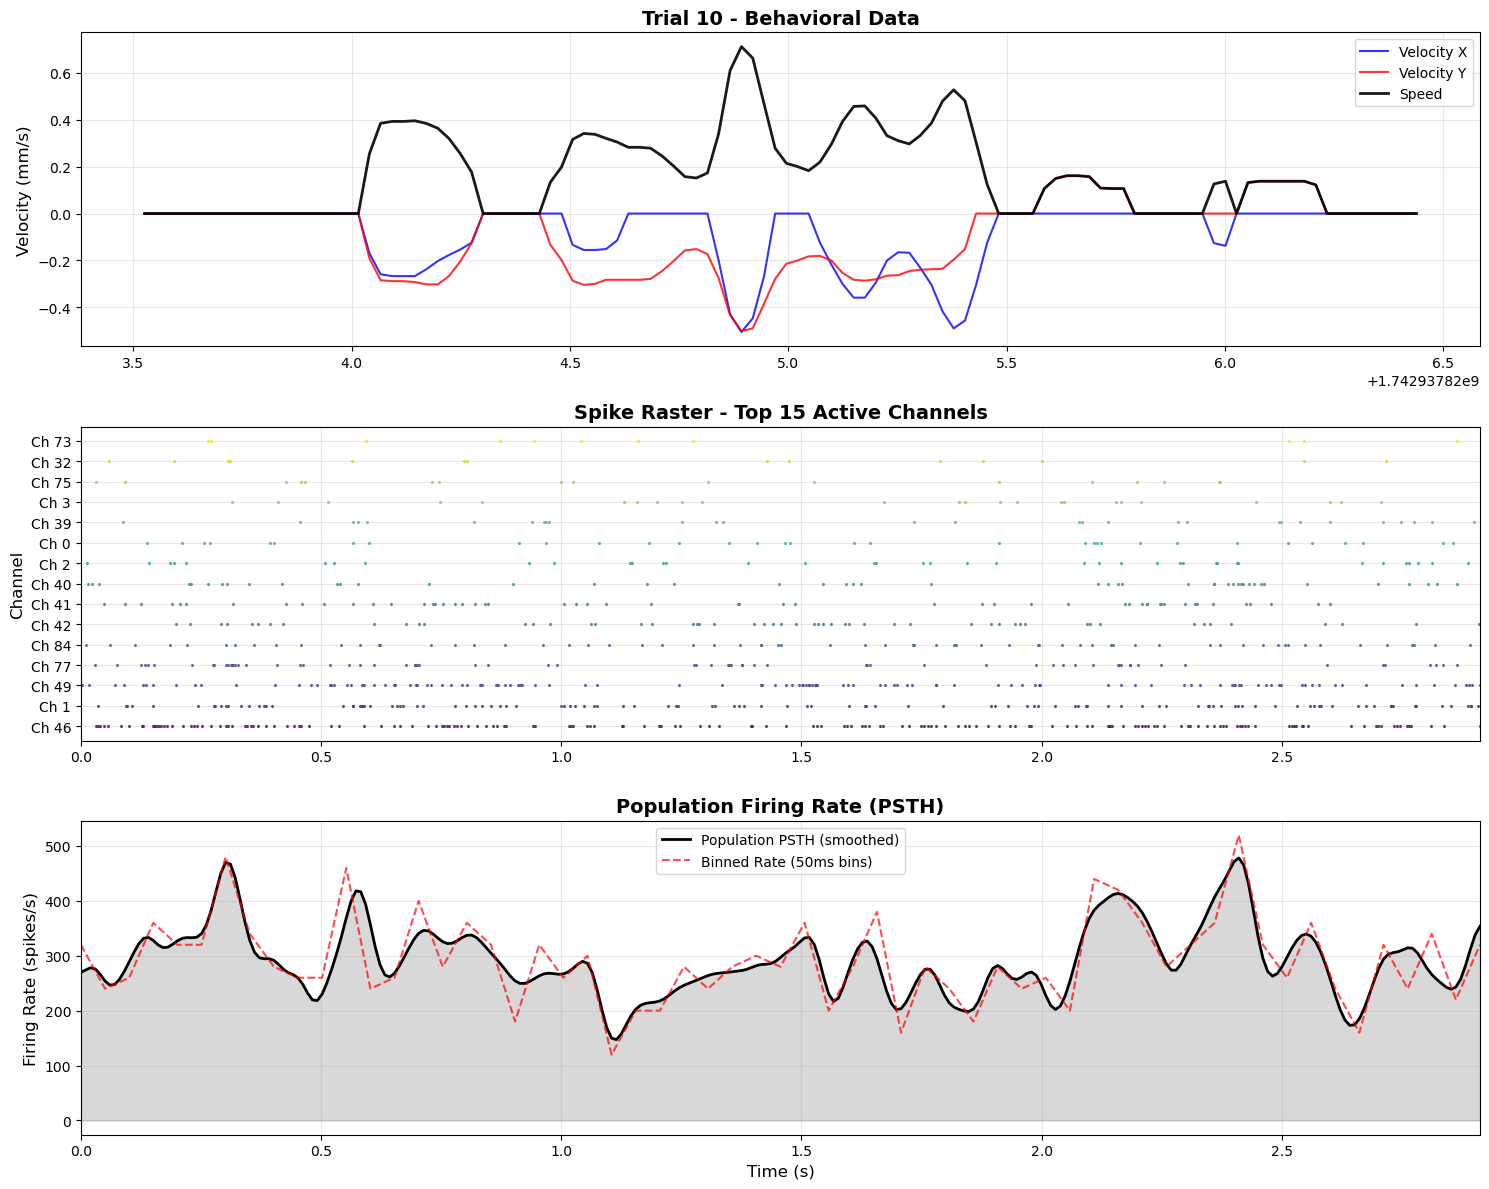

✅ Comprehensive visualization complete!
   • Behavioral data: 114 samples
   • Spike raster: 15 channels
   • Total spikes: 901
   • PSTH resolution: 10ms bins, 25ms smoothing
   • Duration: 2.9s


In [25]:
if analysis_results is not None and analysis_results['success']:
    # Use modular comprehensive visualization function
    from utils.visualization import plot_comprehensive_behavior_raster_psth
    plot_comprehensive_behavior_raster_psth(analysis_results, TRIAL_NUMBER)

else:
    print("❌ Cannot create visualization - no valid analysis results")


In [ ]:
# 🎯 Demonstration: Quick Analysis with Modular Functions
# This cell shows how easy it is to perform comprehensive analysis with the modular approach

print("🚀 QUICK ANALYSIS DEMONSTRATION:")
print("=" * 50)

if analysis_results is not None and analysis_results['success']:
    print("✅ Using existing analysis results for demonstration...")
    
    # 1. Get comprehensive summary in one line
    from utils.analysis import get_comprehensive_trial_summary
    summary = get_comprehensive_trial_summary(analysis_results)
    
    if summary['success']:
        print(f"\n📊 Trial {TRIAL_NUMBER} Summary:")
        print(f"   • Total spikes: {summary['total_spikes']}")
        print(f"   • Mean firing rate: {summary['mean_firing_rate']:.1f} Hz")
        print(f"   • High-quality channels: {summary['high_quality_channels']}")
        print(f"   • Active channels: {summary['active_channels']}")
    
    # 2. Analyze detailed channel with one function call
    from utils.analysis import analyze_channel_detail
    channel_detail = analyze_channel_detail(analysis_results)
    
    if channel_detail['success']:
        channel = channel_detail['channel']
        firing_stats = channel_detail['firing_rate_stats']
        spike_stats = channel_detail['spike_stats']
        
        print(f"\n🔍 Channel {channel} Details:")
        print(f"   • Mean firing rate: {firing_stats['mean_rate']:.1f} Hz")
        print(f"   • Peak firing rate: {firing_stats['max_rate']:.1f} Hz")
        if spike_stats:
            print(f"   • Total spikes: {spike_stats['n_spikes']}")
            print(f"   • Mean ISI: {spike_stats.get('mean_isi', 'N/A'):.1f} ms")
    
    # 3. Quick correlation analysis
    correlation_results = spike_analyzer.analyze_neural_behavioral_correlation(analysis_results)
    
    if correlation_results['success']:
        print(f"\n🔗 Neural-Behavioral Correlation:")
        print(f"   • Population correlation: {correlation_results['population_correlation']:.3f}")
        print(f"   • Top channel correlation: {correlation_results['channel_correlations'][0][1]:.3f} (Ch {correlation_results['channel_correlations'][0][0]})")
    
    print(f"\n💡 All this analysis accomplished with just a few modular function calls!")
    print(f"   The notebook is now clean, readable, and maintainable!")
    
else:
    print("❌ No analysis results available for demonstration")
    print("💡 Run the previous cells to see the modular approach in action!")


🚀 QUICK ANALYSIS DEMONSTRATION:
✅ Using existing analysis results for demonstration...

📊 Trial 10 Summary:
   • Total spikes: 916
   • Mean firing rate: 13.9 Hz
   • High-quality channels: 17
   • Active channels: 7

🔍 Channel 46 Details:
   • Mean firing rate: 56.9 Hz
   • Peak firing rate: 180.0 Hz
   • Total spikes: 178
   • Mean ISI: 17.2 ms

🔗 Neural-Behavioral Correlation:
   • Population correlation: -0.178
   • Top channel correlation: -0.255 (Ch 46)

💡 All this analysis accomplished with just a few modular function calls!
   The notebook is now clean, readable, and maintainable!


: 